In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"add-your-path-here\student-success-predictor")
sys.path.append(str(project_path))

In [ ]:
from utils.data_loader import DataLoader
from utils.data_explorer import DataExplorer
from first_year_persistance_classification.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [3]:
# # Load the CSV
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [4]:
# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [5]:
# Data exploration
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

In [6]:
# column categorization
numeric_cols = ["first_term_gpa", "second_term_gpa", "high_school_average_mark", "math_score"]
binary_cols = ["fast_track", "coop", "residency"]
nominal_cols = ["first_language", "funding", "gender", "previous_education"]
ordinal_cols = ["age_group", "english_grade"]

Class distribution:
first_year_persistence
1.0    1138
0.0     299
Name: count, dtype: int64


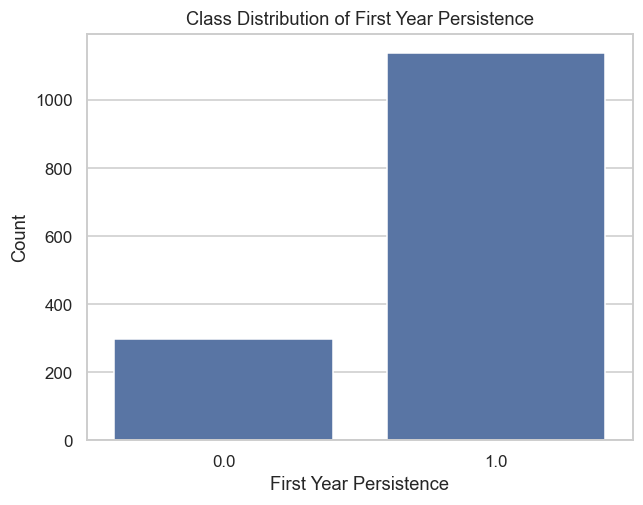

In [7]:
# target variable
target_col = "first_year_persistence"
X = clean_df.drop(columns=[target_col])
y = clean_df[target_col]

# class distribution
print("Class distribution:")
print(y.value_counts())

# plot class distribution
sns.countplot(x=y)
plt.title("Class Distribution of First Year Persistence")
plt.xlabel("First Year Persistence")
plt.ylabel("Count")
plt.show()

In [8]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 0.125 x 0.8 = 0.1 of the original data
    random_state=42,
    stratify=y_train,
)#10% of the original data is used for validation

# Data cleaning
cleaner = DataCleaner(numeric_imputer="random_forest")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

C:\Vivek\Soft\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [9]:
# Check shape of the datasets after cleaning
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (1005, 34)
Validation set shape: (144, 34)
Test set shape: (288, 34)


In [11]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,second_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_term_gpa_missing,...,funding_2,funding_4,funding_5,funding_8,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
712,-2.395317,-2.102637,1,0,0,6,-0.680565,0.225035,7,0,...,False,True,False,False,True,False,False,True,False,False
203,-0.542386,0.378253,0,1,1,6,-1.007294,-1.395073,9,0,...,True,False,False,False,True,False,False,False,True,False
1168,-0.442848,-0.911292,0,0,1,2,-0.164183,-0.995540,4,0,...,True,False,False,False,False,True,False,True,False,False
1029,0.499887,0.257908,0,1,1,2,-1.009172,-1.594840,4,0,...,True,False,False,False,False,True,False,True,False,False
1377,-0.205490,-0.036693,1,0,0,3,-0.256193,0.063224,10,0,...,False,True,False,False,True,False,False,False,True,False


In [12]:
# handle class imbalance with balanced class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(2.4043062200956937), np.int64(1): np.float64(0.6312814070351759)}


In [13]:
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

# model architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.summary()

C:\Vivek\Soft\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           2,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 192 (768.00 B)

In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(project_path / "first_year_persistance_classification/models/best_model.keras", monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5958 - loss: 0.6886 - val_accuracy: 0.7960 - val_loss: 0.4325
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6965 - loss: 0.5442 - val_accuracy: 0.8358 - val_loss: 0.4291
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7139 - loss: 0.5075 - val_accuracy: 0.8607 - val_loss: 0.4400
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7749 - loss: 0.4271 - val_accuracy: 0.8706 - val_loss: 0.4254
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7935 - loss: 0.4428 - val_accuracy: 0.8706 - val_loss: 0.4284
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7973 - loss: 0.4487 - val_accuracy: 0.8756 - val_loss: 0.4088
Epoch 7/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8221 - loss: 0.4085 - val_accuracy: 0.8557 - val_loss: 0.4250
Epoch 8/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8346 - loss: 0.3633 - val_accuracy: 0.8

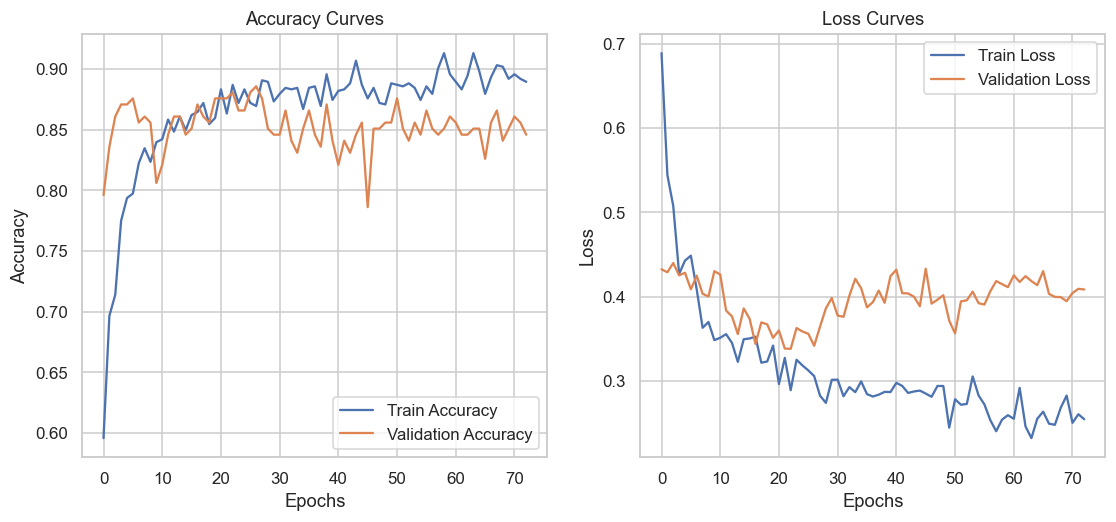

In [16]:
# plot accuracy and loss curves both val and training
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [17]:
# test set evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8576 - loss: 0.3351 


In [20]:
# confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Confusion Matrix:
[[ 40  20]
 [ 21 207]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.67      0.66        60
         1.0       0.91      0.91      0.91       228

    accuracy                           0.86       288
   macro avg       0.78      0.79      0.79       288
weighted avg       0.86      0.86      0.86       288



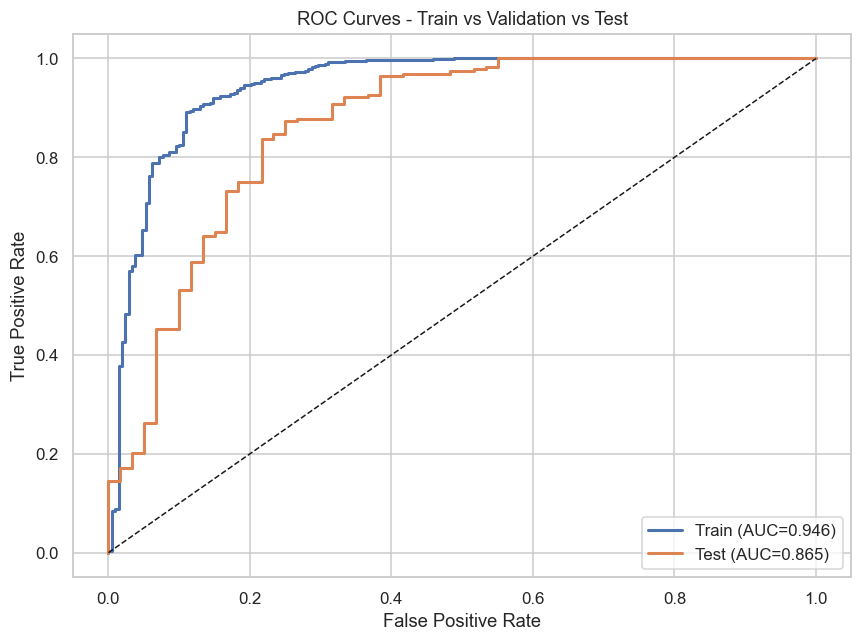

In [21]:
#ROC curve and AUC - TRAIN, VAL and TEST sets
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(model, X_train_scaled, y_train_original,  X_test_scaled, y_test_original):
    y_train_prob = model.predict(X_train_scaled, verbose=0).ravel()
    y_test_prob = model.predict(X_test_scaled, verbose=0).ravel()

    fpr_train, tpr_train, _ = roc_curve(y_train_original, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test_original, y_test_prob)

    auc_train = auc(fpr_train, tpr_train)
    auc_test = auc(fpr_test, tpr_test)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, label=f'Train (AUC={auc_train:.3f})', linewidth=2)
    plt.plot(fpr_test, tpr_test, label=f'Test (AUC={auc_test:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.title('ROC Curves - Train vs Validation vs Test')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_roc_curves(
    model,
    X_train_scaled=X_train,
    y_train_original=y_train,
    X_test_scaled=X_test,
    y_test_original=y_test
)

,Feature Group,Importance Mean,Importance Std
4,second_term_gpa_missing,0.078125,0.009088
5,first_term_gpa,0.038194,0.014813
6,second_term_gpa,0.015972,0.012729
0,first_language,0.009375,0.015086
7,first_term_gpa_missing,0.003472,0.003106
8,age_group,0.003472,0.008784
9,residency,0.001389,0.006054
10,english_grade_missing,0.000694,0.003027
11,age_group_missing,-0.000347,0.001042
2,gender,-0.000347,0.011461


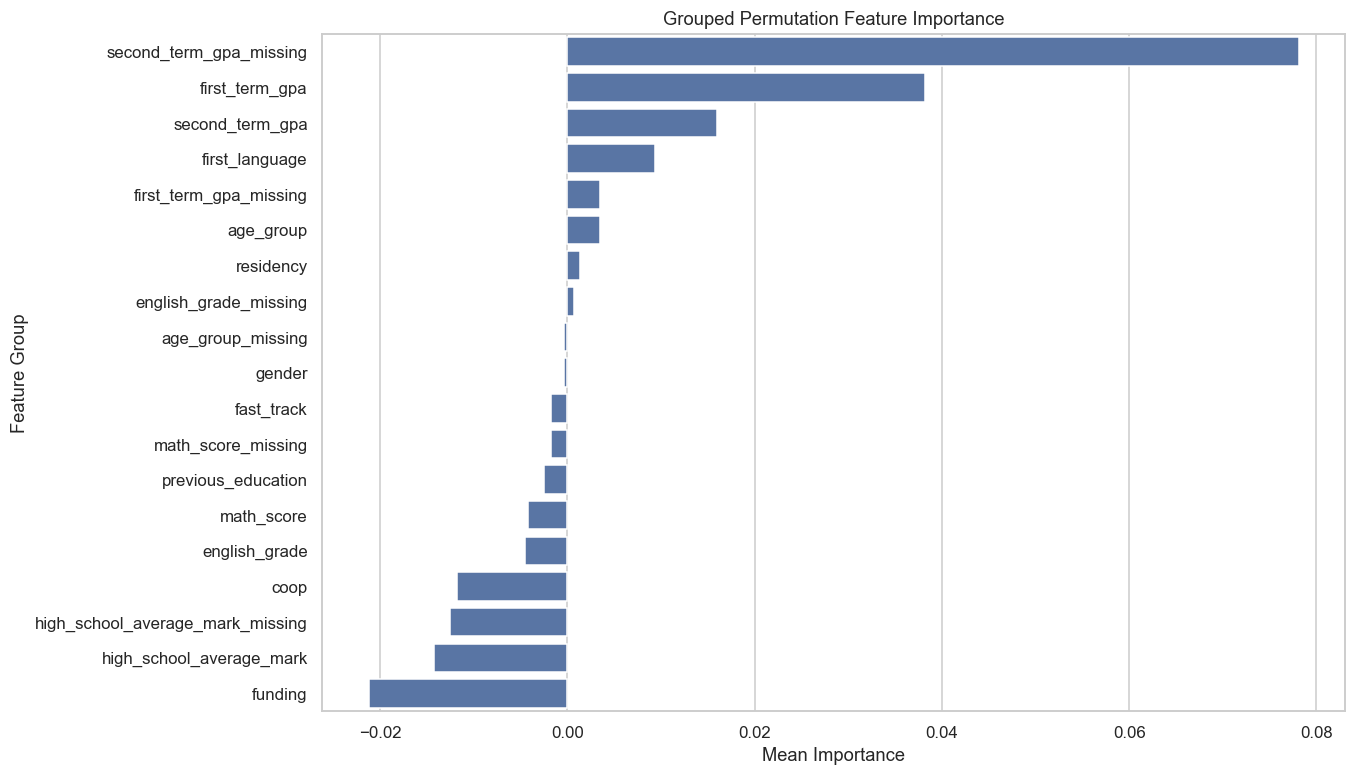

In [22]:
from sklearn.base import BaseEstimator
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class KerasWrapper(BaseEstimator):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()

wrapped_model = KerasWrapper(model)

result = permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# individual feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)


# combine one-hot encoded columns by original feature name
grouped_rows = []

group_prefixes = [
    "first_language",
    "funding",
    "gender",
    "previous_education"
]

used_cols = set()

for prefix in group_prefixes:
    matching = feature_importance_df[feature_importance_df["Feature"].str.startswith(prefix + "_")]
    if not matching.empty:
        grouped_rows.append({
            "Feature Group": prefix,
            "Importance Mean": matching["Importance Mean"].sum(),
            "Importance Std": matching["Importance Std"].sum()
        })
        used_cols.update(matching["Feature"].tolist())

# keep non one-hot columns as they are
remaining = feature_importance_df[~feature_importance_df["Feature"].isin(used_cols)]

for _, row in remaining.iterrows():
    grouped_rows.append({
        "Feature Group": row["Feature"],
        "Importance Mean": row["Importance Mean"],
        "Importance Std": row["Importance Std"]
    })

grouped_importance_df = pd.DataFrame(grouped_rows).sort_values(
    by="Importance Mean", ascending=False
)

display(grouped_importance_df)

# plot grouped importance
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance Mean", y="Feature Group", data=grouped_importance_df)
plt.title("Grouped Permutation Feature Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature Group")
plt.show()

In [34]:
# keras tuner hyperband define neurons, optimizers, and learning rates
import keras
from keras_tuner import Hyperband
import shutil
import time
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def build_tuner_model(hp):
    input_dim = X_train.shape[1]
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])

    for i in range(hp.Int("num_layers", 1, 6)):
        units = hp.Choice(f"neurons_{i}", [64, 128, 256, 512, 1024])
        activation = hp.Choice(f"act_{i}", ["relu", "tanh", "elu", "selu"])
        dropout_rate = hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.2)

        model.add(Dense(units, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    opt = hp.Choice("optimizer", ["adam", "sgd", "rmsprop"])
    lr = hp.Choice("learning_rate", [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1])

    if opt == "adam":
        optimizer = Adam(learning_rate=lr)
    elif opt == "sgd":
        optimizer = SGD(learning_rate=lr, momentum=0.9)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

def show_best_hyperparameters(hyperparameters):
    rows = [{"hyperparameter": key, "value": value} for key, value in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [48]:
tuner_dir = project_path / "first_year_persistance_classification" / "tuner" / "student_tuner"
if tuner_dir.exists():
    shutil.rmtree(tuner_dir)

print("KERAS TUNER SEARCH")

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective="val_accuracy",
    max_epochs=40,
    factor=3,
    directory=str(tuner_dir),
    project_name="student_gpa_search",
    overwrite=True,
    seed=42
)

search_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=0,
    mode="max"
 )

start_time = time.time()
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    class_weight=class_weights,
    callbacks=[search_stop],
    verbose=1
 )
search_time = time.time() - start_time

print(f"Search completed in {search_time / 60:.1f} minutes")
hyperband_tuner.results_summary(num_trials=10)

best_hps_list = hyperband_tuner.get_best_hyperparameters(1)
if not best_hps_list:
    raise RuntimeError("Hyperband completed without any successful trials. Check tuner logs above.")

best_hps = best_hps_list[0]
print("BEST HYPERPARAMETERS")
show_best_hyperparameters(best_hps)

Trial 90 Complete [00h 00m 23s]
val_accuracy: 0.8958333134651184

Best val_accuracy So Far: 0.9305555820465088
Total elapsed time: 00h 21m 42s
Search completed in 21.7 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\student_tuner\student_gpa_search
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0071 summary
Hyperparameters:
num_layers: 1
neurons_0: 512
act_0: relu
dropout_0: 0.5
optimizer: adam
learning_rate: 0.01
neurons_1: 256
act_1: elu
dropout_1: 0.1
neurons_2: 64
act_2: tanh
dropout_2: 0.5
neurons_3: 1024
act_3: tanh
dropout_3: 0.5
neurons_4: 64
act_4: elu
dropout_4: 0.5
neurons_5: 64
act_5: elu
dropout_5: 0.30000000000000004
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0060
Score: 0.9305555820465088

Trial 0075 summary
Hyperparameters:
num_layers: 1
neurons_0: 1024
act_0: tanh
dropout_0: 0.1
optimizer: adam
learning_rate: 0.01
neuro

,hyperparameter,value
0,num_layers,1
1,neurons_0,512
2,act_0,relu
3,dropout_0,0.5
4,optimizer,adam
5,learning_rate,0.01
6,neurons_1,256
7,act_1,elu
8,dropout_1,0.1
9,neurons_2,64


In [49]:
# extracting results from the search as csv with accuracy, val accuracy, loss and val loss
all_trials = list(hyperband_tuner.oracle.trials.values())

results_df = pd.DataFrame([
    {
        "Accuracy": t.metrics.metrics["accuracy"].get_best_value()
            if "accuracy" in t.metrics.metrics else None,
        "Loss": t.metrics.metrics["loss"].get_best_value()
            if "loss" in t.metrics.metrics else None,
        "Val_Accuracy": t.metrics.metrics["val_accuracy"].get_best_value()
            if "val_accuracy" in t.metrics.metrics else None,
        "Val_Loss": t.metrics.metrics["val_loss"].get_best_value()
            if "val_loss" in t.metrics.metrics else None,
        **t.hyperparameters.values
    }
    for t in hyperband_tuner.oracle.trials.values()
]).sort_values("Val_Accuracy", ascending=False)

results_df.insert(0, "ID", range(1, len(results_df) + 1))

results_df.to_csv(
    project_path / "keras_tuner_results.csv",
    index=False
)

In [50]:
print("TOP 20 BEST TRIALS (by Validation Accuracy)")
print(results_df.head(20).to_string(index=False))

TOP 20 BEST TRIALS (by Validation Accuracy)
 ID  Accuracy     Loss  Val_Accuracy  Val_Loss  num_layers  neurons_0 act_0  dropout_0 optimizer  learning_rate  tuner/epochs  tuner/initial_epoch  tuner/bracket  tuner/round  neurons_1 act_1  dropout_1  neurons_2 act_2  dropout_2  neurons_3 act_3  dropout_3  neurons_4 act_4  dropout_4  neurons_5 act_5  dropout_5 tuner/trial_id
  1  0.830846 0.482450      0.930556  0.274229           1       1024  tanh        0.1      adam         0.0100            14                    0              1            0         64  relu        0.1       1024  selu        0.1        256  selu        0.3       64.0  selu        0.1     1024.0  tanh        0.3            NaN
  2  0.835821 0.437965      0.930556  0.254066           6         64  relu        0.5       sgd         0.0050            40                    0              0            0        128  selu        0.1        512  relu        0.1         64   elu        0.5      128.0  relu        0.1      256.

In [63]:
# best model from the search high accuracy and low loss on validation set
overall_best_trial = hyperband_tuner.get_best_hyperparameters(3)[2]
best_model = hyperband_tuner.hypermodel.build(overall_best_trial)
best_model.summary()

# observe training with early stopping and model checkpointing
best_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=0,
    mode="max",
)

checkpoint = ModelCheckpoint(
    filepath=project_path / "first_year_persistance_classification/models/best_model_tuner.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
)

history = best_model.fit(
    X_train, y_train,
    epochs=200,
    class_weight=class_weights,
    validation_data=(X_val, y_val),
    callbacks=[best_stop, checkpoint],
    verbose=1,
)

print("Training completed.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │           2,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 155,649 (608.00 KB)

 Trainable params: 153,345 (599.00 KB)

 Non-trainable params: 2,304 (9.00 KB)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.5970 - loss: 0.7783 - val_accuracy: 0.6389 - val_loss: 0.6620
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6318 - loss: 0.6917 - val_accuracy: 0.8056 - val_loss: 0.5344
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6905 - loss: 0.6042 - val_accuracy: 0.7569 - val_loss: 0.5862
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7035 - loss: 0.5862 - val_accuracy: 0.5972 - val_loss: 0.6577
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7045 - loss: 0.5560 - val_accuracy: 0.8472 - val_loss: 0.4629
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7562 - loss: 0.5320 - val_accuracy: 0.7778 - val_loss: 0.5475
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7881 - loss: 0.4996 - val_accuracy: 0.8472 - val_loss: 0.4498
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8020 - loss: 0.4794 - val_accuracy: 0

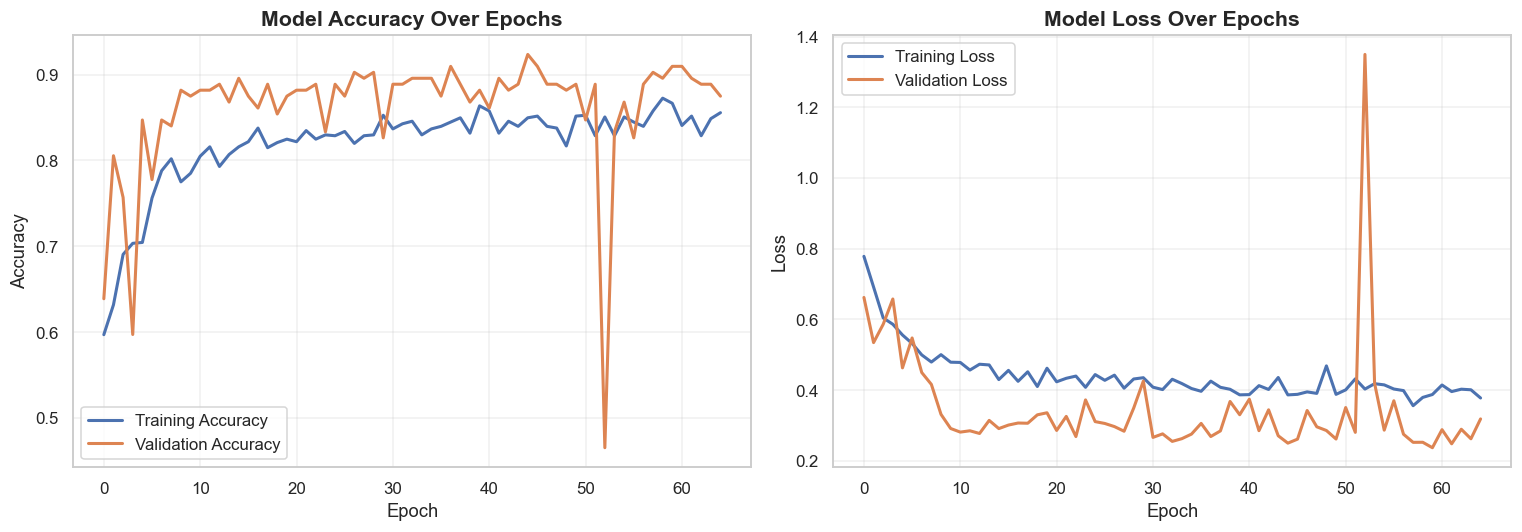


Best Epoch: 45 | Train Acc: 0.8498 | Val Acc: 0.9236 | Train Loss: 0.3865 | Val Loss: 0.2500


In [64]:
def plot_acc_loss_graph(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    def best_metric(name, best):
        return f"{history.history[name][best]:.4f}"

    best = int(np.argmax(history.history['val_accuracy']))

    print( f"\nBest Epoch: {best+1} | Train Acc: {best_metric('accuracy', best)} | Val Acc: {best_metric('val_accuracy', best)} | "
        f"Train Loss: {best_metric('loss', best)} | Val Loss: {best_metric('val_loss', best)}")
# visualize training history 
plot_acc_loss_graph(history)

In [65]:
# evaluate on test set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print("Test Loss: {:.4f} | Test Accuracy: {:.4f}".format(test_loss, test_accuracy))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8924 - loss: 0.2713 
Test Loss: 0.2713 | Test Accuracy: 0.8924


In [66]:
# confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
Confusion Matrix:
[[ 39  21]
 [ 10 218]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.65      0.72        60
         1.0       0.91      0.96      0.93       228

    accuracy                           0.89       288
   macro avg       0.85      0.80      0.82       288
weighted avg       0.89      0.89      0.89       288



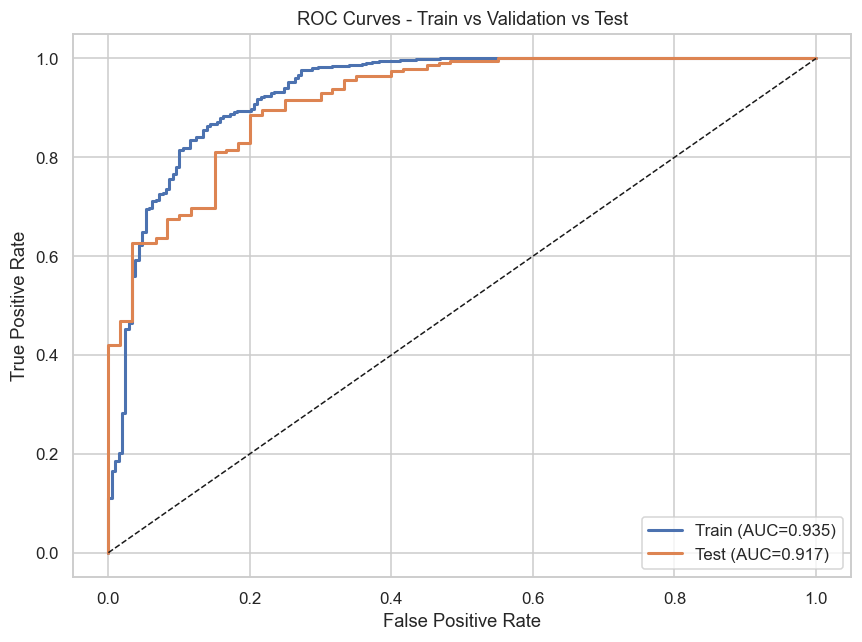

In [67]:

plot_roc_curves(
    best_model,
    X_train_scaled=X_train,
    y_train_original=y_train,
    X_test_scaled=X_test,
    y_test_original=y_test
)

,Feature Group,Importance Mean,Importance Std
4,second_term_gpa_missing,0.096181,0.011625
5,second_term_gpa,0.016667,0.008618
6,first_term_gpa,0.014236,0.014604
7,fast_track,0.007292,0.004238
8,math_score,0.006597,0.005479
3,previous_education,0.004861,0.007569
1,funding,0.004861,0.010623
9,residency,0.004861,0.003867
10,high_school_average_mark,0.004167,0.003027
2,gender,0.003819,0.004918


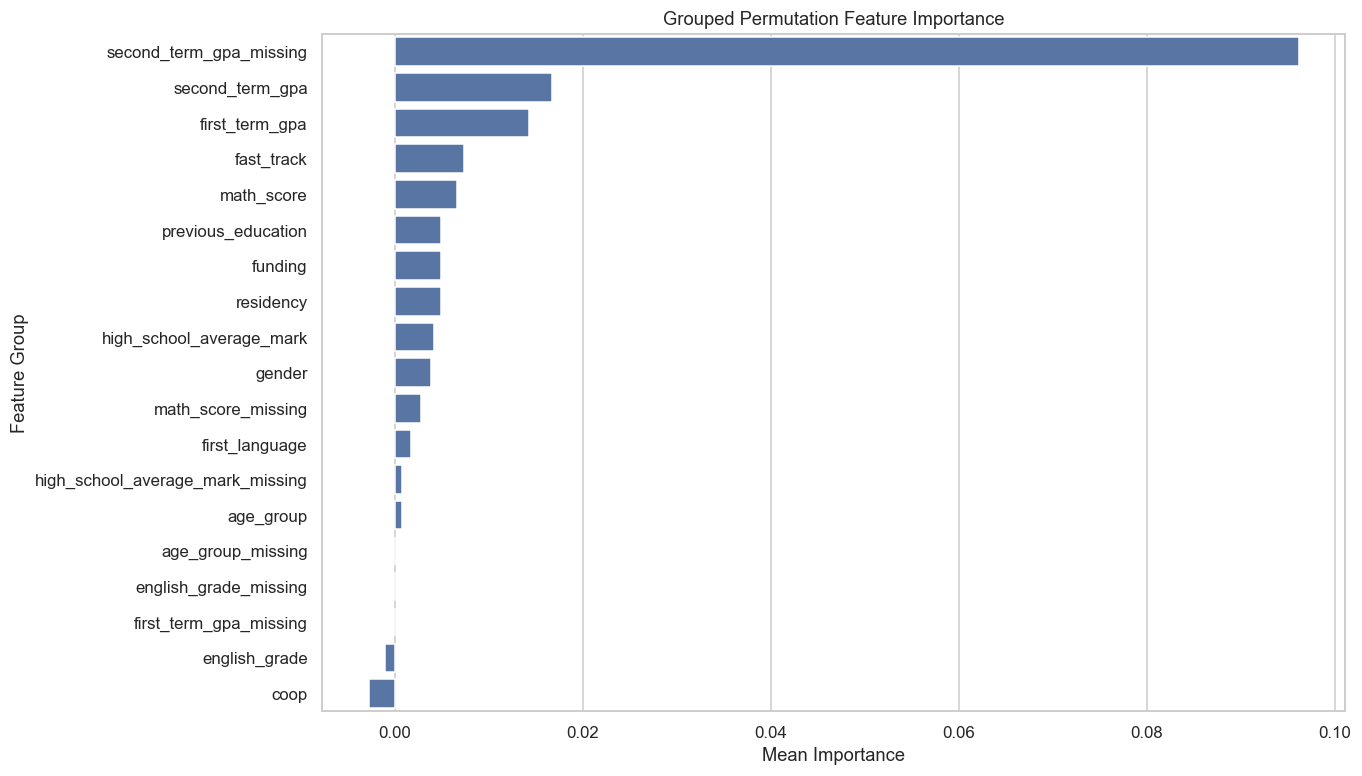

In [68]:

wrapped_model = KerasWrapper(best_model)

result = permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# individual feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)


# combine one-hot encoded columns by original feature name
grouped_rows = []

group_prefixes = [
    "first_language",
    "funding",
    "gender",
    "previous_education"
]

used_cols = set()

for prefix in group_prefixes:
    matching = feature_importance_df[feature_importance_df["Feature"].str.startswith(prefix + "_")]
    if not matching.empty:
        grouped_rows.append({
            "Feature Group": prefix,
            "Importance Mean": matching["Importance Mean"].sum(),
            "Importance Std": matching["Importance Std"].sum()
        })
        used_cols.update(matching["Feature"].tolist())

# keep non one-hot columns as they are
remaining = feature_importance_df[~feature_importance_df["Feature"].isin(used_cols)]

for _, row in remaining.iterrows():
    grouped_rows.append({
        "Feature Group": row["Feature"],
        "Importance Mean": row["Importance Mean"],
        "Importance Std": row["Importance Std"]
    })

grouped_importance_df = pd.DataFrame(grouped_rows).sort_values(
    by="Importance Mean", ascending=False
)

display(grouped_importance_df)

# plot grouped importance
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance Mean", y="Feature Group", data=grouped_importance_df)
plt.title("Grouped Permutation Feature Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature Group")
plt.show()